## NLP Project 3: Movie Review Classification

## Problem Statement

A movie streaming platform receives large numbers of audience reviews for newly released movies and
web series. These reviews contain viewer opinions about acting, storyline, music, direction, and overall
entertainment value. The platform wants to understand audience reactions and classify reviews into
positive, negative, or neutral categories to measure movie popularity and improve content
recommendations. Manual review analysis is not practical due to the huge amount of text data
generated daily.

## Tasks
1. Collect movie review data.
2. Preprocess review text.
3. Build a sentiment classification model.
4. Analyze audience opinions.
5. Visualize sentiment results.

### Installing and Importing libraries

In [70]:
!pip install pandas numpy nltk scikit-learn matplotlib wordcloud

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from wordcloud import WordCloud

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Load Dataset

In [72]:
df = pd.read_csv("IMDB Dataset.csv")

df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [73]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [74]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [76]:
df.shape

(50000, 2)

In [77]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


## Text Preprocessing

In [78]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):

    text = text.lower()

    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

df["clean_review"] = df["review"].apply(preprocess)

df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching 1 oz episode y...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


## TF-IDF Vectorization

In [79]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean_review"])

y = df["sentiment"]

## Train-Test Split

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train Model

In [81]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

## Prediction

In [82]:
prediction = model.predict(X_test)

prediction

array(['negative', 'positive', 'negative', ..., 'positive', 'negative',
       'negative'], dtype='<U8')

## Accuracy

In [83]:
accuracy = accuracy_score(y_test, prediction)

print("Accuracy :", accuracy)

Accuracy : 0.8547


## Classification Report

In [84]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

    negative       0.86      0.85      0.85      4961
    positive       0.85      0.86      0.86      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



## Confusion Matrix

In [85]:
cm = confusion_matrix(y_test, prediction)

print(cm)

[[4214  747]
 [ 706 4333]]


## Sentiment Count

In [86]:
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


## Bar Chart

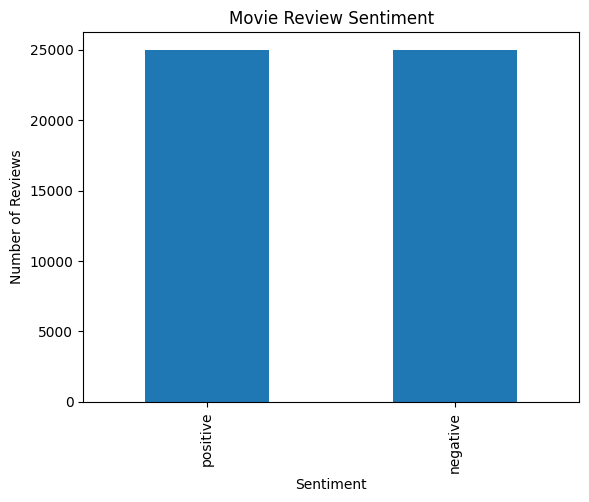

In [87]:
df["sentiment"].value_counts().plot(
    kind="bar"
)

plt.title("Movie Review Sentiment")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.show()

## Pie Chart

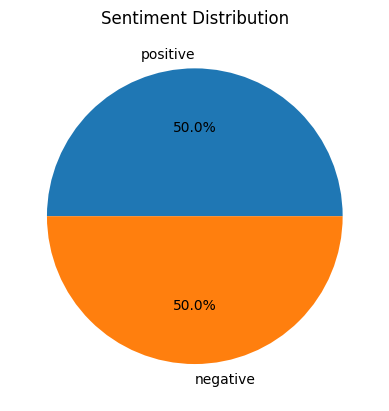

In [88]:
df["sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Sentiment Distribution")

plt.show()

## Word Cloud

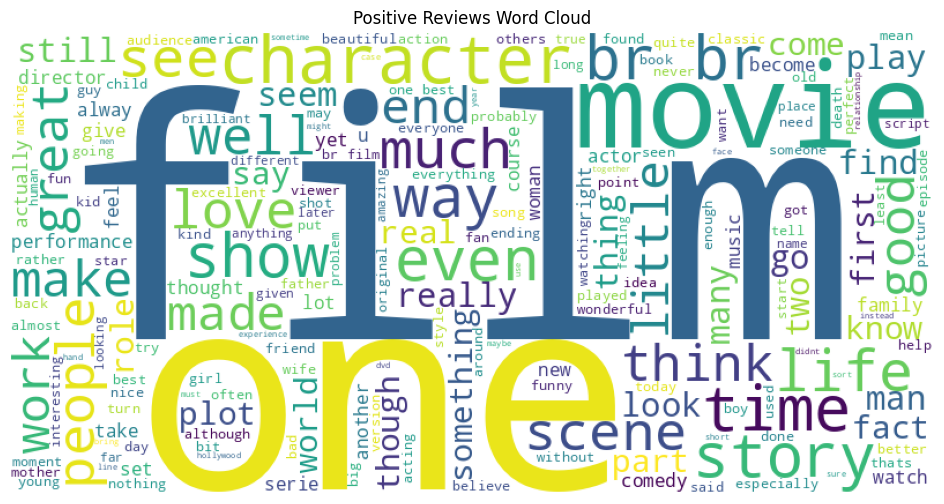

In [89]:
positive_reviews = " ".join(
    df[df["sentiment"]=="positive"]["clean_review"]
)

cloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_reviews)

plt.figure(figsize=(12,6))

plt.imshow(cloud)

plt.axis("off")

plt.title("Positive Reviews Word Cloud")

plt.show()

## Test Your Own Review

In [92]:
review = input("Enter a Movie Review: ")

review = preprocess(review)

review = tfidf.transform([review])

result = model.predict(review)

print("Predicted Sentiment :", result[0])

Enter a Movie Review: one time watch 
Predicted Sentiment : negative
